# Analysis: 20260612

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [1]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [ ]:
data, platemap = pr.load_platereader_data("./data/20250612-cytation3-pure-timecourse-gfp-ppk-biotek-cdk.txt", "20250612-PPK.csv")

# Well A23 (CP + PolyP + 8 mM Mg, replicate 3/3) fits to k~=0 (degenerate/non-responding), which crashes kinetic_analysis's lag-time calculation. Drop it; keep A19/A21 (its two other replicates).
data_drop = data[data["Well"] != "A23"]

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

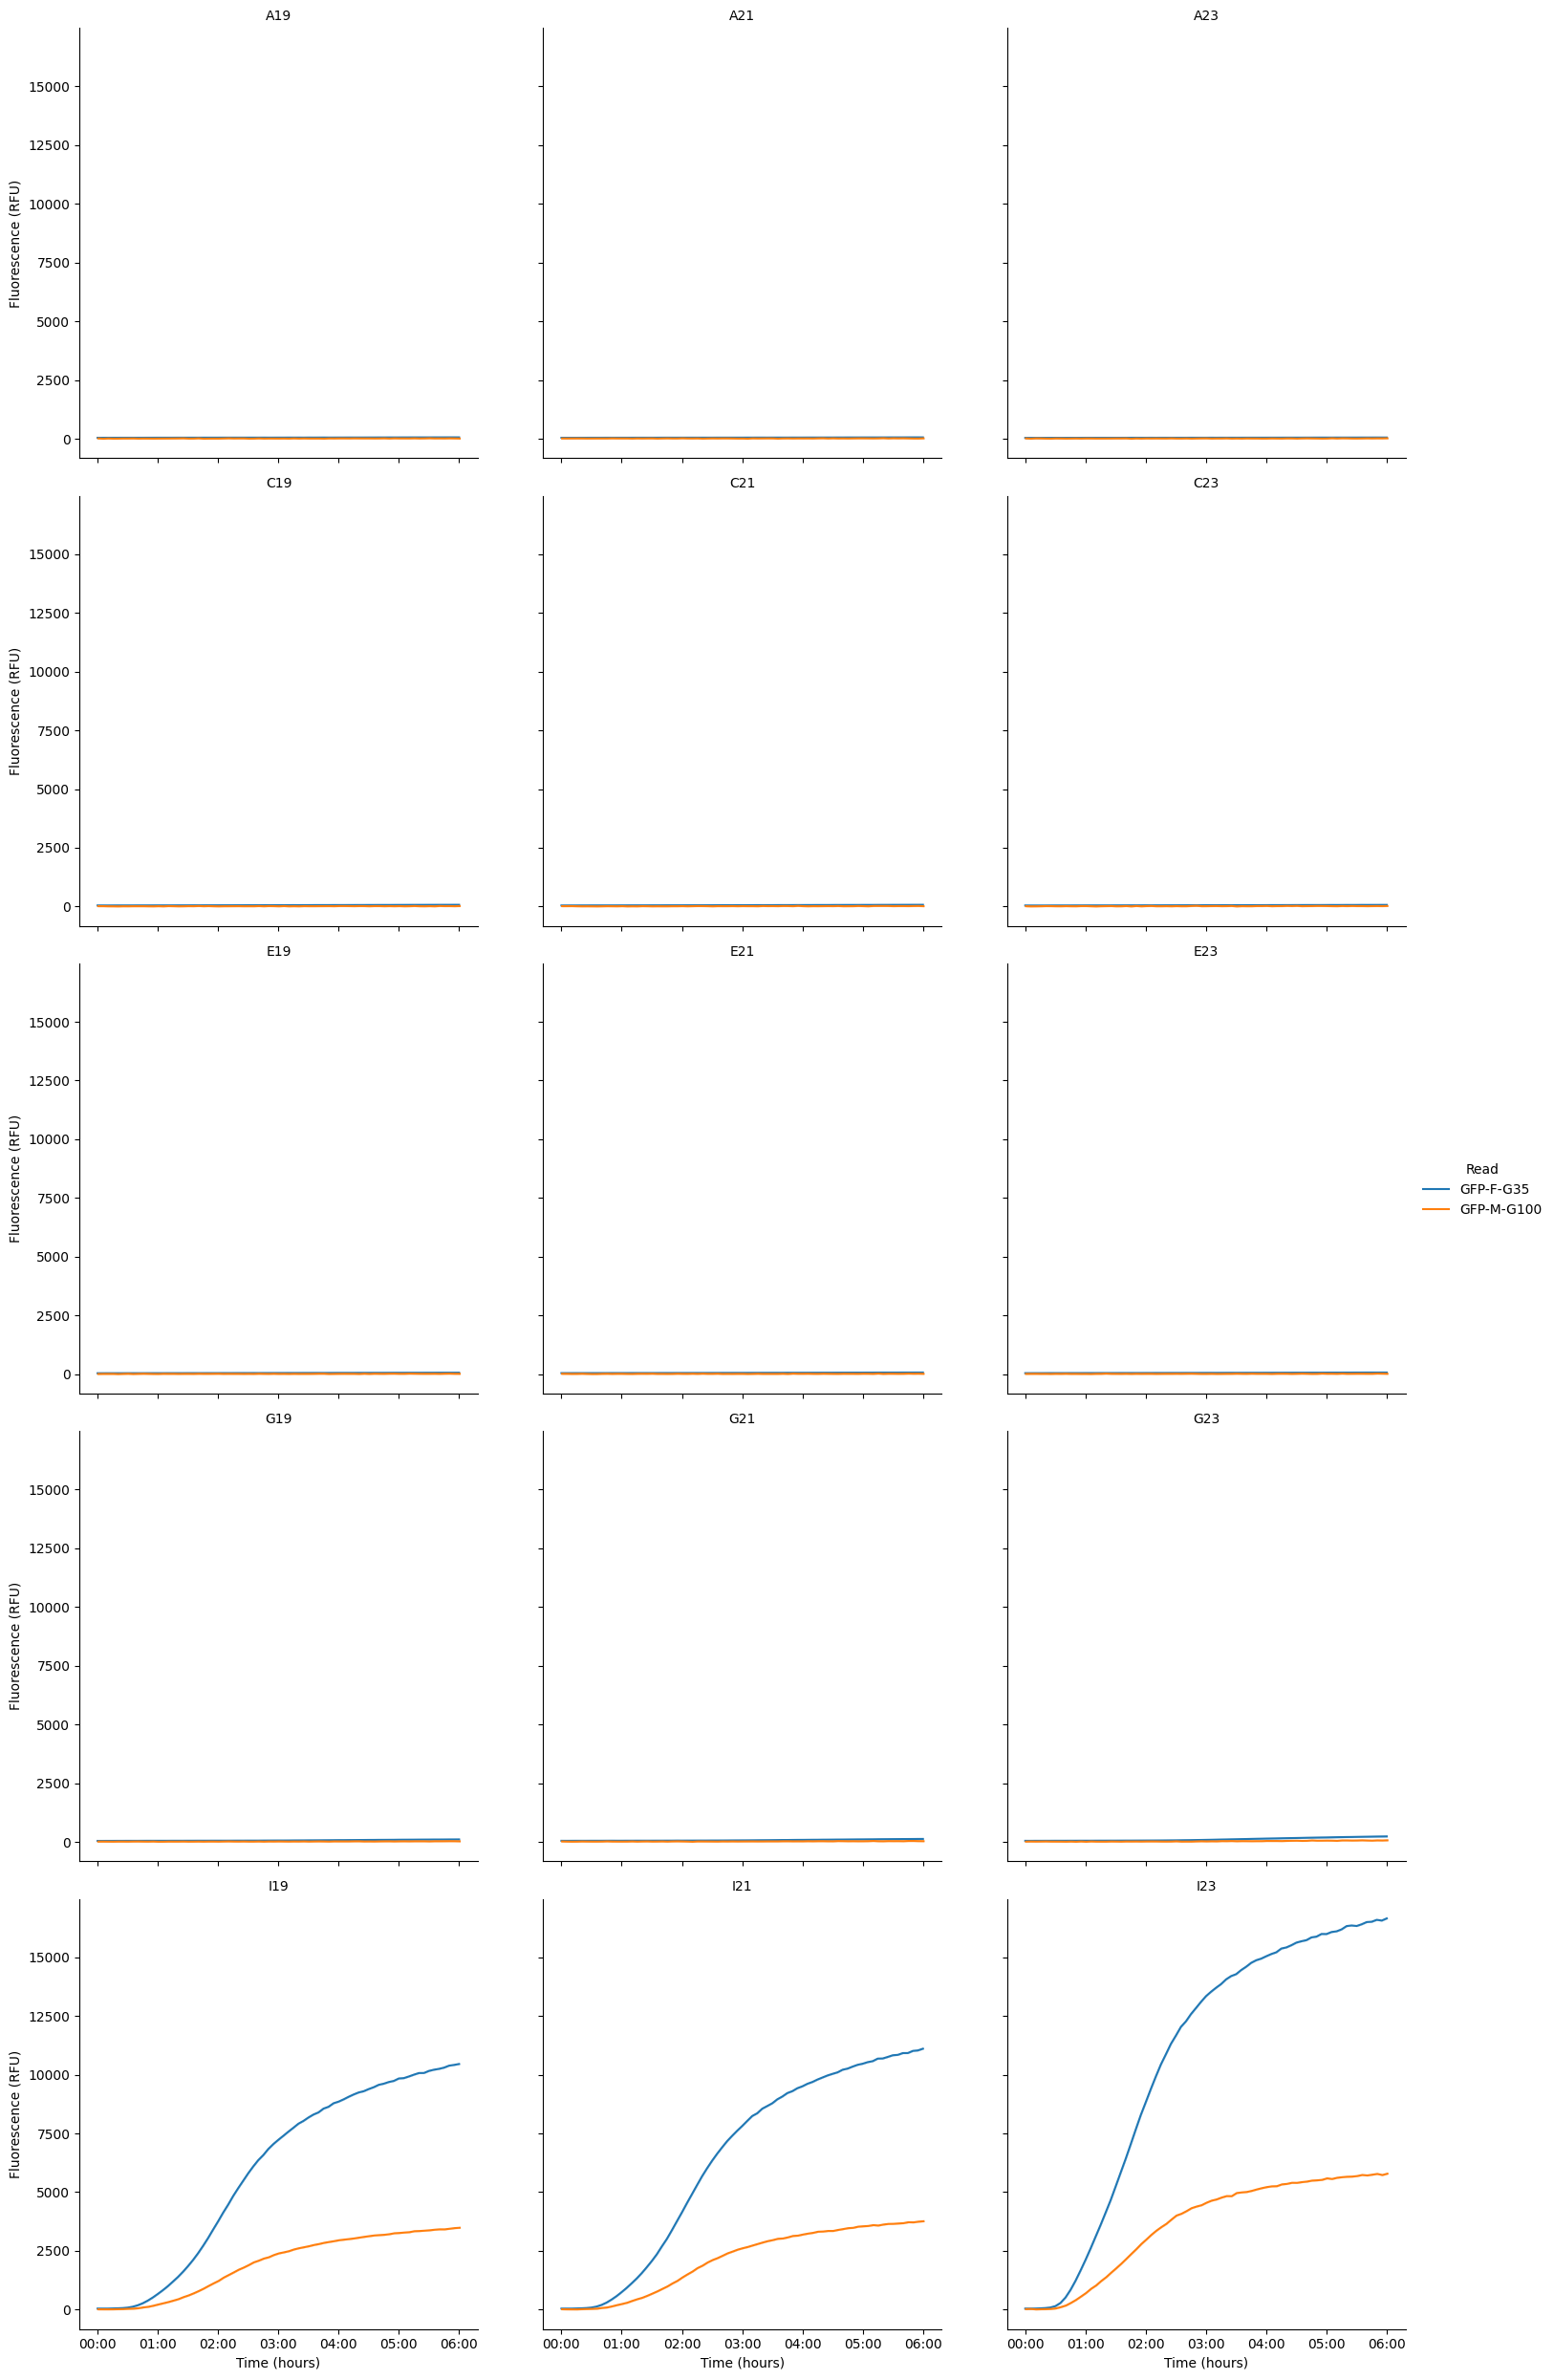

In [3]:
pr.plot_plate(data);

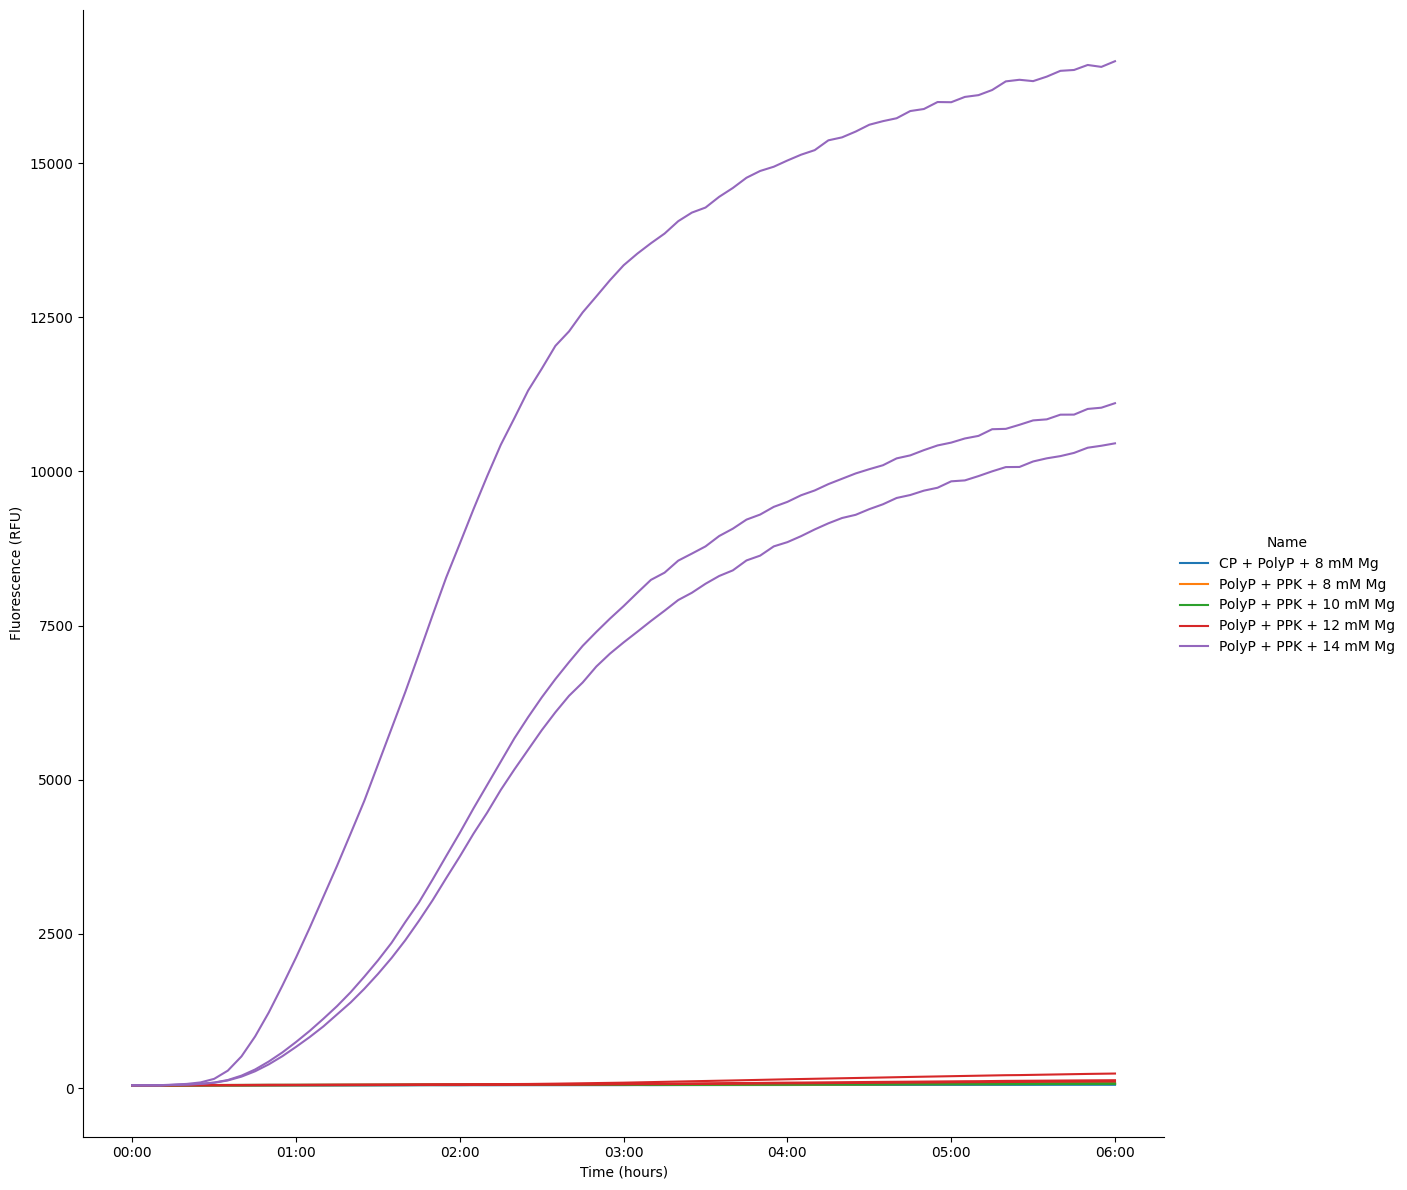

In [32]:
g = pr.plot_curves(data[data["Read"]=="GFP-F-G35"], units="Well", estimator=None, height=12)
g.savefig("plot4")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

In [ ]:
ss = pr.find_steady_state(data_drop[data_drop["Read"]=="GFP-F-G35"], group_by=["Well", "Read"]).reset_index()
ss.columns = [c[0] if c[1] == "" else "_".join(c).strip() for c in ss.columns]
steadystate = data_drop.merge(ss[["Well", "Data_steadystate"]], on="Well", how="left")
steadystate.loc[steadystate["Column"]==13, "Column"] = 14
sns.barplot(data=steadystate, x="Name", y="Data_steadystate", hue="Column")

In [ ]:
#| label: fig:endpoint-exp3

ss= pr.plot_steadystate(data_drop[data_drop["Read"]=="GFP-F-G35"])
plt.xlabel('Condition')
ss.savefig("plot5")

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

In [ ]:
pr.plot_kinetics(data_drop[data_drop["Read"] == "GFP-F-G35"])

We can also calculate the kinetics and display the parameters as a table.

In [ ]:
pr.kinetic_analysis(data_drop)